# Pipeline 2: Resident Reintegration Readiness

## 1. Problem Framing

**Business Problem:** The organization needs to know when a resident is ready for reintegration (family reunification, foster care, or independent living) or at risk of regression. Currently, staff rely on subjective assessments. This pipeline aims to predict reintegration readiness based on objective measures from counseling sessions, education progress, health records, and incident history.

**Who cares:** Social workers, safehouse program directors, and case conference teams.

**Approach:** Both **predictive** (identify residents approaching readiness) and **explanatory** (understand which factors most contribute to successful reintegration). The explanatory model will help staff understand what interventions drive the best outcomes.

**Success Metric:** Accuracy/F1 for predicting reintegration status progression. For explanation, interpretable coefficients showing which intervention categories have the strongest positive effect.

## 2. Data Acquisition, Preparation & Exploration

Tables used:
- `residents.csv` — case status, risk levels, reintegration status
- `process_recordings.csv` — counseling session data (emotional states, progress, concerns)
- `education_records.csv` — education progress, attendance, GPA
- `health_wellbeing_records.csv` — health scores, checkups
- `intervention_plans.csv` — intervention goals and achievement status
- `incident_reports.csv` — behavioral and safety incidents
- `home_visitations.csv` — family cooperation, safety concerns

### Feature Engineering Ideas:
- Average emotional state improvement across sessions
- Session frequency (sessions per month)
- % of sessions with progress noted
- % of sessions with concerns flagged
- Latest education progress percentage
- Latest health score
- Incident count and severity distribution
- Intervention plan achievement rate
- Home visitation favorability rate
- Time in program (length of stay)
- Risk level trajectory (initial vs current)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load data
residents = pd.read_csv('../lighthouse_csv_v7/residents.csv')
process_recordings = pd.read_csv('../lighthouse_csv_v7/process_recordings.csv')
education = pd.read_csv('../lighthouse_csv_v7/education_records.csv')
health = pd.read_csv('../lighthouse_csv_v7/health_wellbeing_records.csv')
interventions = pd.read_csv('../lighthouse_csv_v7/intervention_plans.csv')
incidents = pd.read_csv('../lighthouse_csv_v7/incident_reports.csv')
visitations = pd.read_csv('../lighthouse_csv_v7/home_visitations.csv')

print(f'Residents: {len(residents)}')
print(f'Process Recordings: {len(process_recordings)}')
print(f'Education Records: {len(education)}')
print(f'Health Records: {len(health)}')
print(f'Intervention Plans: {len(interventions)}')
print(f'Incident Reports: {len(incidents)}')
print(f'Home Visitations: {len(visitations)}')

Residents: 60
Process Recordings: 2819
Education Records: 534
Health Records: 534
Intervention Plans: 180
Incident Reports: 100
Home Visitations: 1337


In [8]:
# Explore residents
print('Case status:', residents['case_status'].value_counts().to_dict())
print('\nReintegration status:', residents['reintegration_status'].value_counts().to_dict())
print('\nRisk levels:', residents['current_risk_level'].value_counts().to_dict())
print('\nCase categories:', residents['case_category'].value_counts().to_dict())

Case status: {'Active': 30, 'Closed': 19, 'Transferred': 11}

Reintegration status: {'In Progress': 21, 'Completed': 19, 'On Hold': 13, 'Not Started': 7}

Risk levels: {'Low': 34, 'Medium': 20, 'High': 5, 'Critical': 1}

Case categories: {'Surrendered': 21, 'Abandoned': 18, 'Foundling': 11, 'Neglected': 10}


In [9]:
# Aggregate resident-level features + define target

def _first_existing_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _ensure_datetime(df: pd.DataFrame, col: str) -> pd.Series:
    return pd.to_datetime(df[col], errors='coerce')

resident_id_col = _first_existing_col(residents, ['resident_id', 'residentId', 'residentID', 'id', 'resident_pk'])
if resident_id_col is None:
    raise ValueError(f"Could not find resident id column in residents. cols={list(residents.columns)}")

# Target selection (explicit, stable multiclass mapping)
if 'reintegration_status' not in residents.columns:
    raise ValueError(f"Expected residents to have reintegration_status. cols={list(residents.columns)}")

raw_status = residents['reintegration_status'].astype('string').fillna('Unknown')
print('reintegration_status raw classes:', raw_status.value_counts(dropna=False).to_dict())

KNOWN_STATUSES = {'Not Started', 'In Progress', 'On Hold', 'Completed'}

def _map_status(s: str) -> str:
    s = (s or '').strip()
    return s if s in KNOWN_STATUSES else 'Other'

mapped_status = raw_status.apply(_map_status)
print('reintegration_status mapped classes:', mapped_status.value_counts(dropna=False).to_dict())

# Optionally drop ultra-rare Other
if (mapped_status == 'Other').mean() <= 0.05:
    y = mapped_status.where(mapped_status != 'Other').dropna()
    problem_type = 'multiclass'
    keep_ids = residents.loc[y.index]
else:
    y = mapped_status
    problem_type = 'multiclass'
    keep_ids = residents

print('Problem type:', problem_type)

# Feature builders

def _numeric_aggs(df: pd.DataFrame, group_col: str, prefix: str, extra_aggs: dict | None = None) -> pd.DataFrame:
    """Lightweight numeric aggregation to avoid feature explosion."""
    out = pd.DataFrame(index=df[group_col].dropna().unique())
    out.index.name = group_col

    # Exclude obvious id-like numeric columns
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != group_col]
    num_cols = [c for c in num_cols if not c.lower().endswith('id') and 'id' not in c.lower()]

    # Drop columns that are entirely missing
    num_cols = [c for c in num_cols if df[c].notna().any()]

    if num_cols:
        g = df.groupby(group_col)[num_cols].agg(['mean', 'max'])
        g.columns = [f'{prefix}{c}__{stat}' for c, stat in g.columns]
        out = out.join(g, how='left')

    # Always add row count per resident
    out = out.join(df.groupby(group_col).size().rename(f'{prefix}row_count'), how='left')

    if extra_aggs:
        for name, series in extra_aggs.items():
            out = out.join(series.rename(f'{prefix}{name}'), how='left')

    return out


def _latest_snapshot(df: pd.DataFrame, group_col: str, date_col_candidates: list[str], prefix: str) -> pd.DataFrame:
    date_col = _first_existing_col(df, date_col_candidates)
    if date_col is None:
        return pd.DataFrame(index=pd.Index(df[group_col].dropna().unique(), name=group_col))

    tmp = df.copy()
    tmp[date_col] = _ensure_datetime(tmp, date_col)
    tmp = tmp.dropna(subset=[date_col])
    if tmp.empty:
        return pd.DataFrame(index=pd.Index(df[group_col].dropna().unique(), name=group_col))

    tmp = tmp.sort_values(date_col)
    latest = tmp.groupby(group_col).tail(1).set_index(group_col)

    # Keep only numeric + a few helpful categoricals
    keep_num = latest.select_dtypes(include=[np.number]).columns.tolist()
    keep_cat = [c for c in latest.columns if c not in keep_num and c not in {date_col} and c != group_col]
    keep_cat = keep_cat[:5]

    snap = latest[keep_num + keep_cat].copy()

    # Prefix columns
    snap.columns = [f'{prefix}latest__{c}' for c in snap.columns]
    return snap


def _build_features() -> pd.DataFrame:
    rid = resident_id_col

    # Base: residents table (drop target)
    base = residents.copy().rename(columns={rid: 'resident_id'})
    base = base.drop(columns=['reintegration_status'], errors='ignore')

    # Keep id for joining
    base_ids = base[['resident_id']].copy()

    # Separate feature columns
    X_base = base.drop(columns=['resident_id'], errors='ignore')

    # Aggregations from related tables (only if they have resident id)
    feats = []

    def add_table(df: pd.DataFrame, name: str, date_candidates: list[str]):
        id_col = _first_existing_col(df, ['resident_id', 'residentId', 'residentID', 'resident_fk', 'resident'])
        if id_col is None:
            return
        tmp = df.copy().rename(columns={id_col: 'resident_id'})
        feats.append(_numeric_aggs(tmp, 'resident_id', prefix=f'{name}__'))
        feats.append(_latest_snapshot(tmp, 'resident_id', date_candidates, prefix=f'{name}__'))

    add_table(process_recordings, 'process', ['session_date', 'recording_date', 'created_at', 'date'])
    add_table(education, 'education', ['record_date', 'term_date', 'created_at', 'date'])
    add_table(health, 'health', ['record_date', 'visit_date', 'created_at', 'date'])
    add_table(visitations, 'visitation', ['visit_date', 'created_at', 'date'])

    # Interventions: achievement rate if possible
    id_col = _first_existing_col(interventions, ['resident_id', 'residentId', 'residentID', 'resident_fk', 'resident'])
    if id_col is not None:
        tmp = interventions.copy().rename(columns={id_col: 'resident_id'})
        status_col = _first_existing_col(tmp, ['status', 'achievement_status', 'goal_status', 'is_achieved', 'achieved'])
        extra = {}
        if status_col is not None:
            s = tmp[status_col].astype('string').str.lower().fillna('')
            achieved = s.str.contains('achiev|complete|done|met')
            extra['achievement_rate'] = achieved.groupby(tmp['resident_id']).mean()
        feats.append(_numeric_aggs(tmp, 'resident_id', prefix='intervention__', extra_aggs=extra if extra else None))
        feats.append(_latest_snapshot(tmp, 'resident_id', ['created_at', 'updated_at', 'date'], prefix='intervention__'))

    # Incidents: counts + severity sums if present
    id_col = _first_existing_col(incidents, ['resident_id', 'residentId', 'residentID', 'resident_fk', 'resident'])
    if id_col is not None:
        tmp = incidents.copy().rename(columns={id_col: 'resident_id'})
        sev_col = _first_existing_col(tmp, ['severity', 'incident_severity', 'severity_score'])
        extra = {}
        if sev_col is not None:
            sev = pd.to_numeric(tmp[sev_col], errors='coerce').fillna(0)
            extra['severity_sum'] = sev.groupby(tmp['resident_id']).sum()
            extra['severity_max'] = sev.groupby(tmp['resident_id']).max()
        feats.append(_numeric_aggs(tmp, 'resident_id', prefix='incident__', extra_aggs=extra if extra else None))

    # Combine
    out = base_ids
    for f in feats:
        out = out.merge(f.reset_index(), on='resident_id', how='left')

    # Attach resident base features
    out = out.merge(pd.concat([base_ids, X_base], axis=1), on='resident_id', how='left')
    return out

X = _build_features()
print('Feature rows:', len(X), 'Feature cols:', X.shape[1])

# Merge y back by resident id
rid_map = keep_ids.rename(columns={resident_id_col: 'resident_id'})[['resident_id']].copy()
rid_map['y'] = y.values

data = X.merge(rid_map, on='resident_id', how='inner')
print('Modeling rows (after merge):', len(data))

# Quick missingness overview
missing_pct = data.isna().mean().sort_values(ascending=False).head(15)
print('Top missingness features:')
display(missing_pct)

reintegration_status raw classes: {'In Progress': 21, 'Completed': 19, 'On Hold': 13, 'Not Started': 7}
reintegration_status mapped classes: {'In Progress': 21, 'Completed': 19, 'On Hold': 13, 'Not Started': 7}
Problem type: multiclass
Feature rows: 60 Feature cols: 120
Modeling rows (after merge): 60
Top missingness features:


process__latest__notes_restricted             1.000000
notes_restricted                              1.000000
pwd_type                                      0.950000
special_needs_diagnosis                       0.900000
date_closed                                   0.500000
referring_agency_person                       0.400000
date_colb_obtained                            0.400000
visitation__latest__family_members_present    0.366667
incident__row_count                           0.266667
incident__severity_max                        0.266667
incident__severity_sum                        0.266667
date_colb_registered                          0.216667
date_case_study_prepared                      0.183333
reintegration_type                            0.083333
visitation__latest__visit_type                0.033333
dtype: float64

## 3. Modeling & Feature Selection

Compare:
1. **OLS / Logistic Regression** (explanatory — understand drivers of reintegration success)
2. **Decision Tree** (interpretable, visual — useful for case conference discussions)
3. **Gradient Boosting** (predictive — best accuracy for readiness scoring)

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

# Prepare X/y
if 'y' not in data.columns:
    raise ValueError('Expected data to include y target column.')

# Drop id from features
X = data.drop(columns=['y', 'resident_id'], errors='ignore')
y = data['y']

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler(with_mean=False)),
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

# Choose models (multiclass, consistent imbalance handling)
models = {
    'LogReg': Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', LogisticRegression(
            max_iter=4000,
            class_weight='balanced',
            C=0.3,  # stronger regularization to reduce overfitting risk
        ))
    ]),
    'DecisionTree': Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced',
            max_depth=5,
            min_samples_leaf=5,
        ))
    ]),
    'RandomForest': Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            class_weight='balanced_subsample',
            min_samples_leaf=2,
        ))
    ]),
}

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Score models (macro-F1 emphasizes minority classes)
scoring = 'f1_macro'

results = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    score = f1_score(y_test, pred, average='macro', zero_division=0)
    results.append((name, score))

results = sorted(results, key=lambda x: x[1], reverse=True)
print('Holdout macro-F1 (higher is better):')
for name, score in results:
    print(f'- {name}: {score:.4f}')

best_name = results[0][0]
best_model = models[best_name]
print('\nSelected model:', best_name)

# CV macro-F1 for selected model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring=scoring)
print(f'CV {scoring} (mean±sd): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Holdout macro-F1 (higher is better):
- DecisionTree: 0.4762
- LogReg: 0.4167
- RandomForest: 0.2262

Selected model: DecisionTree
CV f1_macro (mean±sd): 0.3579 ± 0.1399


## 4. Evaluation & Interpretation

**Business interpretation:**
- A false negative (predicting not-ready when ready) delays reintegration and can increase program costs.
- A false positive (predicting ready prematurely) can create safety risk.

Given the stakes, we should usually be **conservative**: optimize for **precision** on the "ready" decision (or on the most-advanced reintegration class), while monitoring recall so we don’t ignore strong candidates.

## 5. Causal and Relationship Analysis

This pipeline identifies **associations** (correlates) that are useful for prioritization and case conference discussion, not guaranteed causal effects.

- Many signals (incident counts, counseling trends, education progress) can reflect underlying context (family stability, trauma history, resource constraints).
- Use the model’s top drivers to form **intervention hypotheses**, then validate with staff review and, when possible, structured pilots (e.g., comparing outcomes before/after an intervention protocol change).

## 6. Deployment Notes

Keep this notebook as the **reference** feature + training pipeline. Production scoring should mirror the same feature definitions and serve results at `/api/ml/reintegration-readiness`.

- **Scoring output**: `resident_id`, `readiness_probability` (or predicted class), plus a `risk_band` / `readiness_band`.
- **UI integration**: show a readiness score and top factors to support case conference.
- **Safety**: treat predictions as decision support; require staff confirmation before any reintegration step.

Next we run a focused evaluation and extract the model’s top drivers for interpretability.

              precision    recall  f1-score   support

   Completed      0.600     0.750     0.667         4
 In Progress      0.667     0.500     0.571         4
 Not Started      0.000     0.000     0.000         1
     On Hold      0.667     0.667     0.667         3

    accuracy                          0.583        12
   macro avg      0.483     0.479     0.476        12
weighted avg      0.589     0.583     0.579        12



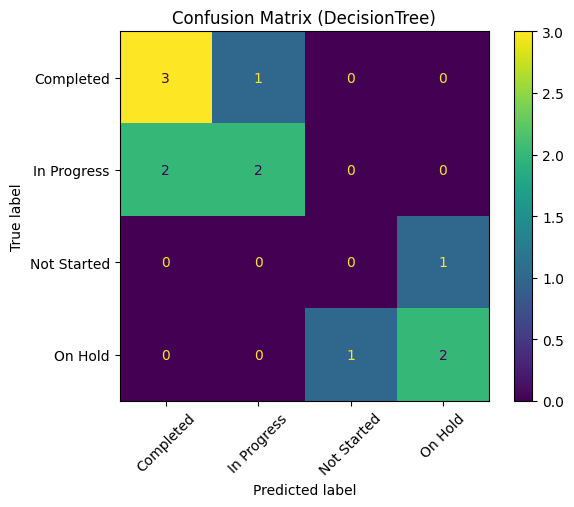


Top absolute drivers for class: Completed


,feature,coef,abs_coef
36,visitation__row_count,0.278178,0.278178
41,intervention__achievement_rate,-0.186556,0.186556
47,safehouse_id,-0.179236,0.179236
13,health__general_health_score__mean,-0.176784,0.176784
6,education__attendance_rate__max,0.159116,0.159116
143,education__latest__notes_Progress: Completed,-0.155701,0.155701
141,education__latest__completion_status_Completed,-0.155701,0.155701
142,education__latest__completion_status_InProgress,0.155627,0.155627
144,education__latest__notes_Progress: InProgress,0.155627,0.155627
690,date_colb_obtained_2023-06-21,0.140238,0.140238



Top absolute drivers for class: In Progress


,feature,coef,abs_coef
36,visitation__row_count,0.234336,0.234336
47,safehouse_id,0.190783,0.190783
8,education__progress_percent__max,0.175881,0.175881
30,health__latest__nutrition_score,0.162281,0.162281
16,health__nutrition_score__max,0.150818,0.150818
15,health__nutrition_score__mean,0.147615,0.147615
14,health__general_health_score__max,-0.145767,0.145767
427,birth_status_Non-Marital,0.143229,0.143229
426,birth_status_Marital,-0.143071,0.143071
12,education__latest__progress_percent,0.142252,0.142252



Top absolute drivers for class: Not Started


,feature,coef,abs_coef
36,visitation__row_count,-0.259044,0.259044
242,intervention__latest__services_provided_Teaching,0.161813,0.161813
13,health__general_health_score__mean,0.158634,0.158634
491,family_informal_settler_True,0.147066,0.147066
490,family_informal_settler_False,-0.146913,0.146913
70,process__latest__emotional_state_observed_Sad,0.130125,0.130125
27,health__row_count,-0.127119,0.127119
9,education__row_count,-0.127119,0.127119
14,health__general_health_score__max,0.118855,0.118855
236,intervention__latest__services_provided_Legal ...,0.110945,0.110945



Top absolute drivers for class: On Hold


,feature,coef,abs_coef
36,visitation__row_count,-0.253470,0.253470
15,health__nutrition_score__mean,-0.235080,0.235080
30,health__latest__nutrition_score,-0.161812,0.161812
1,process__session_duration_minutes__max,-0.158451,0.158451
16,health__nutrition_score__max,-0.149765,0.149765
13,health__general_health_score__mean,0.144325,0.144325
41,intervention__achievement_rate,0.141609,0.141609
376,case_status_Active,0.136528,0.136528
50,process__latest__social_worker_SW-05,0.131579,0.131579
837,date_closed_2023-11-25,0.129746,0.129746



Top feature importances (DecisionTree):


,feature,importance
36,visitation__row_count,0.231406
16,health__nutrition_score__max,0.192208
30,health__latest__nutrition_score,0.190871
13,health__general_health_score__mean,0.164434
18,health__sleep_quality_score__max,0.138543
26,health__bmi__max,0.082539
603,present_age_20 Years 0 months,0.000000
604,present_age_20 Years 3 months,0.000000
612,length_of_stay_1 Years 10 months,0.000000
606,length_of_stay_0 Years 6 months,0.000000


In [11]:
# Evaluation + interpretability

best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

if problem_type == 'multiclass':
    print(classification_report(y_test, pred, digits=3))
    labels = sorted(pd.Series(y_test).astype('string').unique().tolist())
    cm = confusion_matrix(y_test, pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(xticks_rotation=45)
    plt.title(f'Confusion Matrix ({best_name})')
    plt.show()
else:
    # binary
    print(classification_report(y_test, pred, digits=3))
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['not_ready', 'ready'])
    disp.plot()
    plt.title(f'Confusion Matrix ({best_name})')
    plt.show()

# Driver extraction
# - Logistic regression coefficients (regularized)
# - Tree/ensemble feature importances (when available)

# Logistic regression drivers
interp_lr = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=6000, class_weight='balanced', C=0.3))
])
interp_lr.fit(X_train, y_train)

try:
    fn = interp_lr.named_steps['preprocess'].get_feature_names_out()
    coef = interp_lr.named_steps['model'].coef_

    # multiclass: show top drivers per class
    for i, cls in enumerate(interp_lr.named_steps['model'].classes_):
        c = coef[i]
        tmp = pd.DataFrame({'feature': fn, 'coef': c})
        tmp['abs_coef'] = tmp['coef'].abs()
        tmp = tmp.sort_values('abs_coef', ascending=False)
        print(f'\nTop absolute drivers for class: {cls}')
        display(tmp.head(15)[['feature', 'coef', 'abs_coef']])
except Exception as e:
    print('Could not extract logistic regression coefficients:', e)

# Feature importances from the selected model when available
try:
    fitted = best_model.named_steps['model']
    if hasattr(fitted, 'feature_importances_'):
        fn = best_model.named_steps['preprocess'].get_feature_names_out()
        imp = fitted.feature_importances_
        imp_df = pd.DataFrame({'feature': fn, 'importance': imp}).sort_values('importance', ascending=False)
        print(f'\nTop feature importances ({best_name}):')
        display(imp_df.head(25))
except Exception as e:
    print('Could not extract feature importances:', e)

In [ ]:
# --- Export holdout predictions for web layer ---
import os

OUT_DIR = '../ml-outputs/reintegration-readiness'
os.makedirs(OUT_DIR, exist_ok=True)

# Align resident_id for X_test rows
if 'data' in globals() and 'resident_id' in data.columns:
    meta = data.loc[X_test.index, ['resident_id']].copy()
else:
    # fallback: create empty meta if something changed upstream
    meta = pd.DataFrame(index=X_test.index)

pred_df = meta.copy()
pred_df['y_true'] = pd.Series(y_test).astype('string').values
pred_df['y_pred'] = pd.Series(pred).astype('string').values

# Probabilities when supported
try:
    if hasattr(best_model, 'predict_proba'):
        proba = best_model.predict_proba(X_test)
        classes = [str(c) for c in best_model.classes_]
        for i, cls in enumerate(classes):
            pred_df[f'p_{cls}'] = proba[:, i]
except Exception as e:
    print('Could not compute predict_proba for export:', e)

pred_path = os.path.join(OUT_DIR, 'predictions.csv')
pred_df.to_csv(pred_path, index=False)
print('Wrote:', pred_path)

pred_df.head(10)